In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Loading data
df = pd.read_csv('q2_customers.csv')

# 2. Scaling features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

# 3. Creating a DataFrame with the scaled features
df_scaled = pd.DataFrame(scaled_features, columns=df.columns)

# 4. Saving to CSV
df_scaled.to_csv('q2_customers_scaled.csv', index=False)

# Why Scaling is Essential Before Applying K-MeansScaling

 Your features before feeding them into a K-Means algorithm is a crucial preprocessing step for the following reasons:

 ##

  ## 1. Distance-Based Algorithm:
  K-Means clustering relies heavily on distance metrics (specifically the Euclidean distance) to measure the similarity between data points and assign them to the closest cluster centroid.
  
  ## 2. Dominance of Large Magnitudes:
  If the dataset contains features with vastly different scales the algorithm will inherently give disproportionately high weight to the features with the larger numerical magnitudes. In our dataset, a difference of 100 in annual_spend is small, but a difference of 100 in age or num_categories_purchased is impossible. Without scaling, the distance calculated would be almost entirely driven by annual_spend.

  ## 3. Equal Contribution:
  Standardizing the data using StandardScaler centers the distribution of each feature around a mean of $0$ and a standard deviation of $1$. This forces every feature to contribute proportionately to the final distance calculations, enabling K-Means to find accurate and meaningful clusters based on all variables, rather than just the ones with the largest numbers.

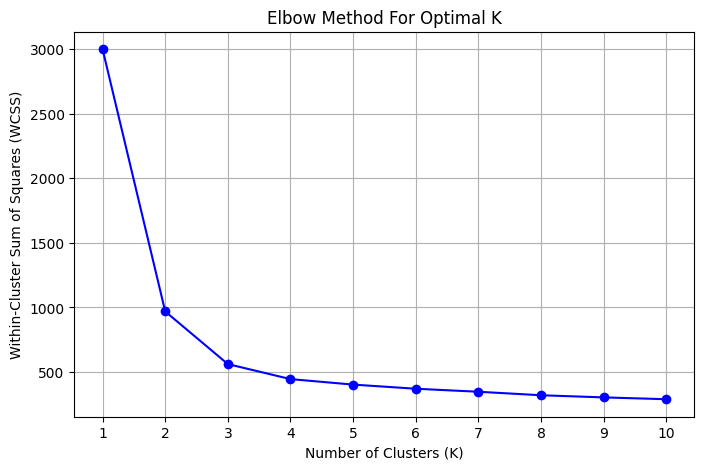

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


df_scaled = pd.read_csv('q2_customers_scaled.csv')

# Calculating WCSS for K=1 to 10
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Ploting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.savefig('elbow_plot.png')

#Justification:
The Elbow Method helps identify the point where adding more clusters no longer yields a significant decrease in the Within-Cluster Sum of Squares (WCSS).
- At $K=1$, the WCSS is 3000.00.
- At $K=2$, it drops drastically to 968.99.
- At $K=3$, it drops further to 561.25.
- From $K=4$ onwards (444.93, 402.37, 370.39...), the curve flattens out, and the marginal reduction in WCSS becomes minimal.

In [5]:
import pandas as pd
from sklearn.cluster import KMeans

df = pd.read_csv('q2_customers.csv')
df_scaled = pd.read_csv('q2_customers_scaled.csv')

# Fitting K-Means with optimal K=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)

# Adding cluster labels to the original dataframe
df['cluster'] = cluster_labels

# Calculating centroids on the ORIGINAL scale for readable interpretation
centroids = df.groupby('cluster').mean()

print("Cluster Centroids (Original Scale):")
print(centroids.round(2))

df.to_csv('q2_customers_clustered.csv', index=False)

Cluster Centroids (Original Scale):
           age  annual_spend  visits_per_month  basket_size  \
cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        56.77      89413.33              2.53      5530.55   
2        40.39      43340.73              8.19      2021.68   

         days_since_last_visit  num_categories_purchased  
cluster                                                   
0                         9.08                      2.11  
1                       105.36                      7.52  
2                        35.19                      4.42  


In [6]:
import pandas as pd
from sklearn.decomposition import PCA


df_scaled = pd.read_csv('q2_customers_scaled.csv')

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_scaled)

# Print Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance Ratio:\nPC1: {explained_variance[0]:.4f}\nPC2: {explained_variance[1]:.4f}")
print(f"Total Explained Variance: {sum(explained_variance):.4f}")

# Create and print Feature Loadings DataFrame
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df_scaled.columns
)
print("\nFeature Loadings:")
print(loadings.round(4))

Explained Variance Ratio:
PC1: 0.8356
PC2: 0.0557
Total Explained Variance: 0.8913

Feature Loadings:
                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405


#Interpretation of Principal Components (PC1 and PC2)

$Principal Component 1 (PC1):The High-Value / Low-Frequency  Dimension$
PC1 is by far the most important component, capturing 83.56% of the total variance in the data. Looking at the loadings:

- Strong Positive Drivers: annual_spend (0.4215), num_categories_purchased (0.4140), basket_size (0.4120), and age (0.4116).

- Strong Negative Driver: visits_per_month (-0.4104).

- Meaning: PC1 distinguishes between two primary types of shoppers. A high positive score on PC1 represents an older customer who spends a lot of money overall, buys huge baskets across many categories, but visits infrequently. A low/negative score on PC1 represents a younger shopper who visits extremely often but spends very little per trip and buys fewer categories. This dimension directly mimics the extreme ends of our K-Means clusters (Cluster 1 vs. Cluster 0).

$Principal Component 2 (PC2):"The Recency (Churn Risk) Dimension"$

PC2 captures an additional 5.57% of the variance. Looking at the loadings:

- Overwhelming Positive Driver: days_since_last_visit (0.9112).

- Meaning: PC2 acts almost entirely as an indicator of Recency. Because its loading on days_since_last_visit is so massive compared to everything else, a high score on PC2 isolates customers who haven't visited the store in a long time, regardless of whether they are high spenders or low spenders.

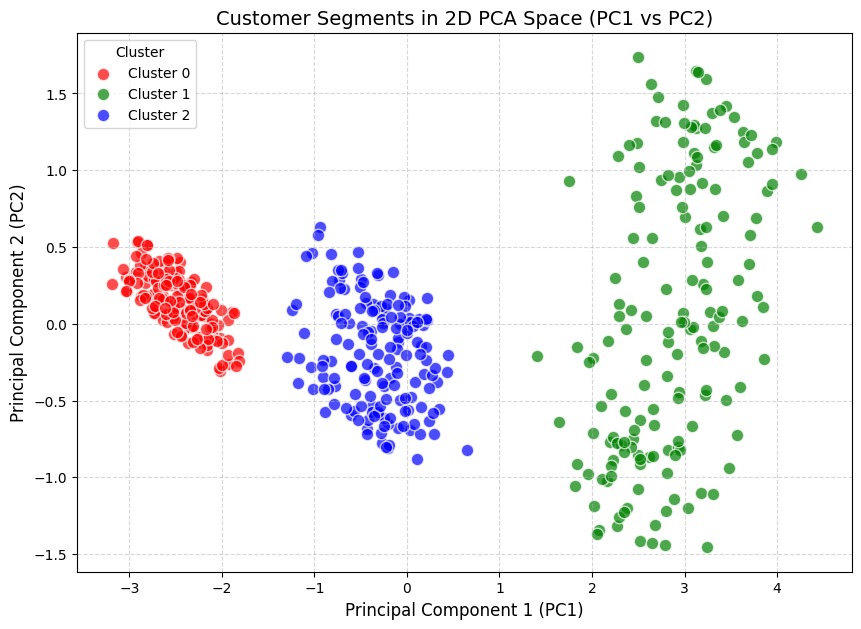

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


df_scaled = pd.read_csv('q2_customers_scaled.csv')
df_clustered = pd.read_csv('q2_customers_clustered.csv')

# Re-applying PCA to get the components
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_scaled)

# Creating a DataFrame combining PCs and Cluster labels
plot_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])
plot_df['Cluster'] = df_clustered['cluster']

# Creating the scatter plot
plt.figure(figsize=(10, 7))

# Defining colors for clusters
colors = ['red', 'green', 'blue']
for cluster_id in sorted(plot_df['Cluster'].unique()):
    subset = plot_df[plot_df['Cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'],
                label=f'Cluster {cluster_id}',
                alpha=0.7,
                c=colors[cluster_id],
                edgecolors='w',
                s=80)

# Adding title, labels, and legend
plt.title('Customer Segments in 2D PCA Space (PC1 vs PC2)', fontsize=14)
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.legend(title='Cluster', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Saving the plot
plt.savefig('pca_clusters.png', bbox_inches='tight')